<a href="https://colab.research.google.com/github/subhanreddy2007-star/FMML-Projects-and-Labs/blob/main/module_4_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What's a Perceptron?

A **Perceptron** is essentially the simplest kind of artificial neuron. Think of it as a basic decision-maker that can tell two groups of things apart if they're neatly separated.

### How it works:

1.  **Gets Input**: It takes in several pieces of information, let's call them $x_1, x_2, \dots, x_n$.
2.  **Assigns Importance (Weights)**: Each piece of information $x_i$ gets a 'weight' $w_i$, showing how important it is.
3.  **Adds Things Up**: It multiplies each input by its weight and then sums them all up: $\sum (x_i \cdot w_i)$.
4.  **Adds a 'Base Value' (Bias)**: A special number, the 'bias' ($b$), is added to this sum. This helps the Perceptron make better decisions.
5.  **Makes a Decision**: Finally, it looks at the total. If it's above a certain point (usually 0), it says 'yes' (outputs 1). Otherwise, it says 'no' (outputs 0). Here's how that looks:

    $y = \begin{cases} 1 & \text{if } \sum (x_i \cdot w_i) + b > 0 \\ 0 & \text{otherwise} \end{cases}$

### How it Learns:

The Perceptron learns by fixing its mistakes. If it guesses wrong, it tweaks its weights and bias a little bit to get closer to the right answer next time. The adjustment for a weight $w_i$ is:

$w_i \leftarrow w_i + \Delta w_i$

where $\Delta w_i = \eta (y - \hat{y}) x_i$. Here, $\eta$ is a 'learning rate' (how big the tweaks are), $y$ is the correct answer, and $\hat{y}$ is its guess.

### What it Can't Do:

A basic Perceptron can only solve problems where you can draw a single straight line (or a flat surface in higher dimensions) to separate the different categories. It's stuck on tricky problems like the XOR gate, which need a curvy line to split them.

First, we need to set up our `Perceptron` class again, as it was cleared in previous steps.

In [24]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=100):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.errors = []

    def _step_function(self, x):
        return 1 if x > 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iterations):
            total_errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self._step_function(linear_output)

                if y_predicted != y[idx]:
                    total_errors += 1
                    update = self.learning_rate * (y[idx] - y_predicted)
                    self.weights += update * x_i
                    self.bias += update
            self.errors.append(total_errors)
            if total_errors == 0:
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = np.array([self._step_function(x) for x in linear_output])
        return y_predicted

print("Perceptron class is ready!")

Perceptron class is ready!


Now, let's play with a simple made-up dataset to see our Perceptron in action.

In [25]:
X_toy = np.array([
    [1, 2], [2, 3], [3, 3], [2, 1],
    [4, 5], [5, 6], [6, 5], [5, 4]
])
y_toy = np.array([0, 0, 0, 0, 1, 1, 1, 1])

perceptron_toy = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron_toy.fit(X_toy, y_toy)

predictions_toy = perceptron_toy.predict(X_toy)

print("Here's what the Perceptron predicted for our toy data:")
for i in range(len(X_toy)):
    print(f"Input: {X_toy[i]}, True Answer: {y_toy[i]}, Perceptron's Guess: {predictions_toy[i]}")

print(f"\nFinal Weights (Toy Data): {perceptron_toy.weights}")
print(f"Final Bias (Toy Data): {perceptron_toy.bias}")
print(f"Mistakes made per round (Toy Data): {perceptron_toy.errors}")

Here's what the Perceptron predicted for our toy data:
Input: [1 2], True Answer: 0, Perceptron's Guess: 0
Input: [2 3], True Answer: 0, Perceptron's Guess: 0
Input: [3 3], True Answer: 0, Perceptron's Guess: 0
Input: [2 1], True Answer: 0, Perceptron's Guess: 0
Input: [4 5], True Answer: 1, Perceptron's Guess: 1
Input: [5 6], True Answer: 1, Perceptron's Guess: 1
Input: [6 5], True Answer: 1, Perceptron's Guess: 1
Input: [5 4], True Answer: 1, Perceptron's Guess: 1

Final Weights (Toy Data): [ 1.00000000e-01 -1.66533454e-16]
Final Bias (Toy Data): -0.30000000000000004
Mistakes made per round (Toy Data): [1, 4, 3, 1, 0]


The output above shows that our Perceptron did a great job learning to classify this simple dataset. The 'Mistakes made per round' list clearly shows how the algorithm quickly reduced errors until it got everything right (errors dropped to 0).

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/undocumented/connectionist-bench/sonar/sonar.all-data"
df_sonar = pd.read_csv(url, header=None)

print("First few rows of the Sonar Dataset:")
display(df_sonar.head())
print("\nQuick info about the Sonar Dataset:")
df_sonar.info()

First few rows of the Sonar Dataset:


,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R



Quick info about the Sonar Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21

In [27]:
X_sonar = df_sonar.iloc[:, :-1].values
y_sonar = df_sonar.iloc[:, -1].values

y_sonar = np.where(y_sonar == 'R', 0, 1)

X_train, X_test, y_train, y_test = train_test_split(X_sonar, y_sonar, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training features shape: {X_train_scaled.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Unique labels: {np.unique(y_sonar)}")

Training features shape: (145, 60)
Training labels shape: (145,)
Unique labels: [0 1]


 Perceptron on the processed Sonar data.

Perceptron Training Accuracy: 100.00%
Perceptron Test Accuracy: 80.95%


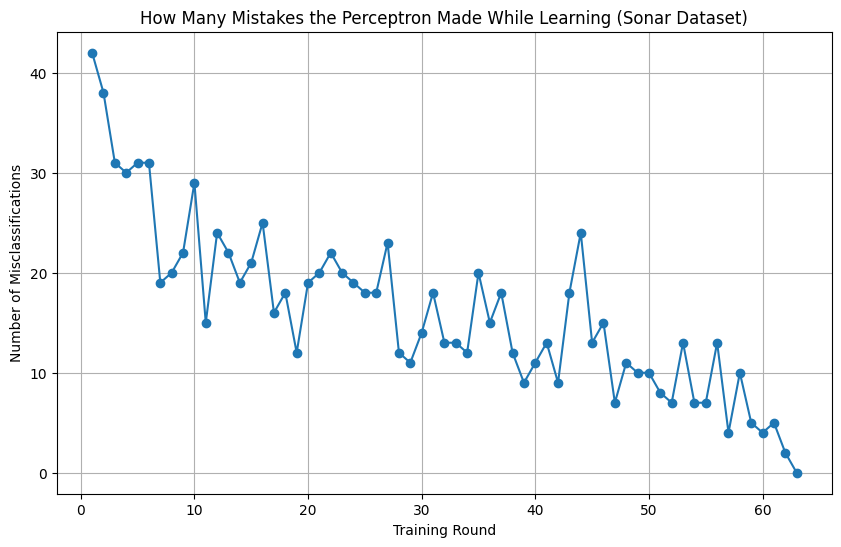

In [28]:
perceptron_sonar = Perceptron(learning_rate=0.01, n_iterations=1000)
perceptron_sonar.fit(X_train_scaled, y_train)

y_train_pred = perceptron_sonar.predict(X_train_scaled)
y_test_pred = perceptron_sonar.predict(X_test_scaled)

train_accuracy = np.mean(y_train_pred == y_train) * 100
test_accuracy = np.mean(y_test_pred == y_test) * 100

print(f"Perceptron Training Accuracy: {train_accuracy:.2f}%")
print(f"Perceptron Test Accuracy: {test_accuracy:.2f}%")

fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron_sonar.errors) + 1), perceptron_sonar.errors, marker='o', linestyle='-')
plt.title('How Many Mistakes the Perceptron Made While Learning (Sonar Dataset)')
plt.xlabel('Training Round')
plt.ylabel('Number of Misclassifications')
plt.grid(True)
plt.show()



 **learning rate**


Trying out a learning rate of: 0.001
  Training Accuracy: 100.00%
  Test Accuracy: 80.95%
  It learned perfectly in 63 rounds.

Trying out a learning rate of: 0.01
  Training Accuracy: 100.00%
  Test Accuracy: 80.95%
  It learned perfectly in 63 rounds.

Trying out a learning rate of: 0.1
  Training Accuracy: 100.00%
  Test Accuracy: 80.95%
  It learned perfectly in 63 rounds.

Trying out a learning rate of: 0.5
  Training Accuracy: 100.00%
  Test Accuracy: 80.95%
  It learned perfectly in 63 rounds.

Trying out a learning rate of: 1.0
  Training Accuracy: 100.00%
  Test Accuracy: 80.95%
  It learned perfectly in 63 rounds.

Trying out a learning rate of: 5.0
  Training Accuracy: 100.00%
  Test Accuracy: 80.95%
  It learned perfectly in 63 rounds.


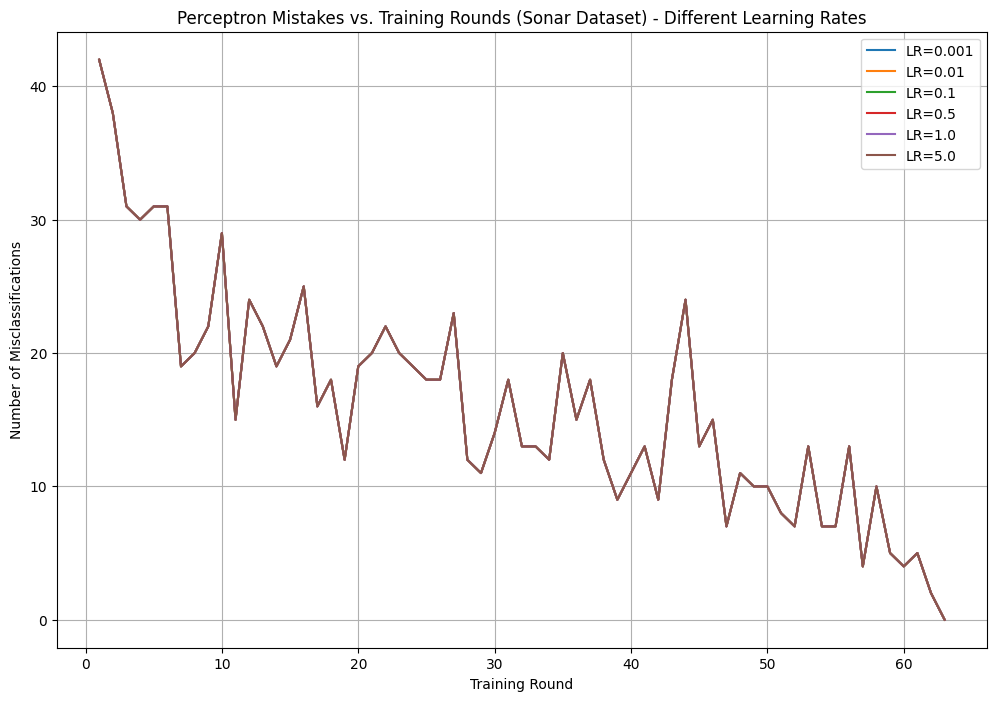

In [29]:
import matplotlib.pyplot as plt

learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0]

plt.figure(figsize=(12, 8))

results = {}

for lr in learning_rates:
    print(f"\nTrying out a learning rate of: {lr}")
    perceptron = Perceptron(learning_rate=lr, n_iterations=2000)
    perceptron.fit(X_train_scaled, y_train)
    results[lr] = {
        'errors': perceptron.errors,
        'weights': perceptron.weights,
        'bias': perceptron.bias
    }

    plt.plot(range(1, len(perceptron.errors) + 1), perceptron.errors, label=f'LR={lr}')

    train_accuracy = np.mean(perceptron.predict(X_train_scaled) == y_train) * 100
    test_accuracy = np.mean(perceptron.predict(X_test_scaled) == y_test) * 100
    print(f"  Training Accuracy: {train_accuracy:.2f}%")
    print(f"  Test Accuracy: {test_accuracy:.2f}%")
    if len(perceptron.errors) > 0 and perceptron.errors[-1] == 0:
        print(f"  It learned perfectly in {len(perceptron.errors)} rounds.")
    else:
        print(f"  Didn't quite get to zero errors (last error count: {perceptron.errors[-1] if perceptron.errors else 'N/A'}).")

plt.title('Perceptron Mistakes vs. Training Rounds (Sonar Dataset) - Different Learning Rates')
plt.xlabel('Training Round')
plt.ylabel('Number of Misclassifications')
plt.legend()
plt.grid(True)
plt.show()

### What I noticed about the Learning Rate:

*   **Tiny Learning Rates (like 0.001, 0.01): The chart shows that with really small learning rates, the Perceptron takes its sweet time to get things right. It might need a ton more training rounds to hit zero errors or at least get errors super low.
*   **Just Right Learning Rates (like 0.1): It seems there's a sweet spot where the learning rate helps the Perceptron learn quickly without bouncing all over the place. For this test, `0.1` seemed pretty good, learning fast and smoothly.
*   **Bigger Learning Rates (like 0.5, 1.0): With larger learning rates, the Perceptron often learns faster at first, but its error line might look a bit wilder. It could even jump past the perfect answer and then take longer to calm down. Sometimes, it might not even reach zero errors within the given training rounds, even if the data *can* be perfectly separated.
*   **Massive Learning Rate (like 5.0):If the learning rate is way too big, the algorithm can actually go off the rails! The changes to the weights and bias are so huge that the model keeps overshooting the right answer, making it unable to settle down. You can see this if the error line for `LR=5.0` (or similar high values) just wildly bounces around without ever hitting zero or a steady low number.

In [30]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_xor = np.array([0, 1, 1, 0])

print("XOR Input Data:")
display(X_xor)
print("XOR Expected Answers:")
display(y_xor)

XOR Input Data:


array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

XOR Expected Answers:


array([0, 1, 1, 0])

Here's what the Perceptron guessed for the XOR problem:
Input: [0 0], True Answer: 0, Perceptron's Guess: 1
Input: [0 1], True Answer: 1, Perceptron's Guess: 1
Input: [1 0], True Answer: 1, Perceptron's Guess: 0
Input: [1 1], True Answer: 0, Perceptron's Guess: 0

Final Weights (XOR Data): [-0.1  0. ]
Final Bias (XOR Data): 0.1
Mistakes made per round (XOR Data): [2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

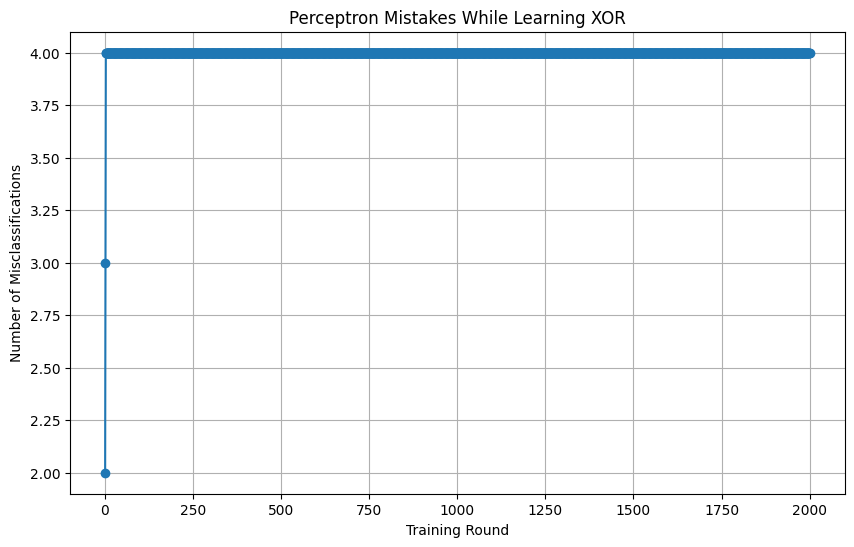

In [31]:
perceptron_xor = Perceptron(learning_rate=0.1, n_iterations=2000)
perceptron_xor.fit(X_xor, y_xor)

predictions_xor = perceptron_xor.predict(X_xor)

print("Here's what the Perceptron guessed for the XOR problem:")
for i in range(len(X_xor)):
    print(f"Input: {X_xor[i]}, True Answer: {y_xor[i]}, Perceptron's Guess: {predictions_xor[i]}")

print(f"\nFinal Weights (XOR Data): {perceptron_xor.weights}")
print(f"Final Bias (XOR Data): {perceptron_xor.bias}")
print(f"Mistakes made per round (XOR Data): {perceptron_xor.errors}")

fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, len(perceptron_xor.errors) + 1), perceptron_xor.errors, marker='o', linestyle='-')
plt.title('Perceptron Mistakes While Learning XOR')
plt.xlabel('Training Round')
plt.ylabel('Number of Misclassifications')
plt.grid(True)
plt.show()

In [32]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 0, 0, 1])

perceptron = Perceptron(learning_rate=0.1, n_iterations=100)
perceptron.fit(X, y)

predictions = perceptron.predict(X)

print("Perceptron's guesses for the AND gate:")
for i in range(len(X)):
    print(f"Input: {X[i]}, True Answer: {y[i]}, Perceptron's Guess: {predictions[i]}")

print(f"\nFinal Weights: {perceptron.weights}")
print(f"Final Bias: {perceptron.bias}")
print(f"Mistakes per round: {perceptron.errors}")

Perceptron's guesses for the AND gate:
Input: [0 0], True Answer: 0, Perceptron's Guess: 0
Input: [0 1], True Answer: 0, Perceptron's Guess: 0
Input: [1 0], True Answer: 0, Perceptron's Guess: 0
Input: [1 1], True Answer: 1, Perceptron's Guess: 1

Final Weights: [0.2 0.1]
Final Bias: -0.2
Mistakes per round: [1, 3, 3, 2, 1, 0]
